# MARICL — Multi-Agent Residual In-Context Learning

A faithful implementation of MARICL (Multi-Agent Residual In-Context Learning)
following the equations in the methods section, using **LangChain** + the **OpenAI API**.

MARICL learns $K$ closed-form *correction agents* on top of a pretrained base model
$f_{\\text{ML}}$. Each agent pairs a natural-language explanation $T_k$ with an executable
formula $f_k$. Predictions are formed as

$$\\hat{y}_{\\text{MARICL}}(\\mathbf{x}) = f_{\\text{ML}}(\\mathbf{x}) + \\sum_{k=1}^{K} \\alpha_k(\\mathbf{x})\\,f_k(\\mathbf{x})\\qquad\\text{(regression)}$$

$$P_{\\text{MARICL}}(\\mathbf{x}) = \\beta\\, P_{\\text{ML}}(\\mathbf{x}) + (1-\\beta)\\sum_{k=1}^{K} \\alpha_k(\\mathbf{x})\\,Q_k(\\mathbf{x})\\qquad\\text{(classification)}$$

The core framework lives in **`maricl_core.py`** (sandbox, models, prompts, pipeline).
This notebook covers:

1. **Setup** — install deps, imports, API key, load `maricl_core`.
2. **Experiment 1** — synthetic regression.
3. **Experiment 2** — synthetic 3-class classification.


## 1. Setup

Install LangChain + OpenAI + standard ML deps. If you already have them, skip the next cell.

In [1]:
%pip install -q langchain langchain-openai openai pydantic numpy scikit-learn matplotlib python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, re, ast, math, random, warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Callable, Any

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, r2_score,
                             accuracy_score, f1_score, log_loss)

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage

warnings.filterwarnings("ignore")
np.random.seed(0); random.seed(0)
print("env ready")

env ready


### API key

The next cell loads **`OPENAI_API_KEY`** from a **`.env`** file next to this notebook (project root), if present. You can also set `OPENAI_API_KEY` or `API_KEY` in the environment before running.

We use **`gpt-5.4-mini`** (override with **`MAICL_MODEL_NAME`**). For GPT-5 family models, **`OPENAI_REASONING_EFFORT`** defaults to `low` (set to `none` to disable).

In [3]:
from pathlib import Path

try:
    from dotenv import load_dotenv
    load_dotenv(Path.cwd().resolve() / ".env")
except ImportError:
    pass

# Normalize key from .env or env (API_KEY alias matches maricl_synthetic_demo.ipynb)
_key = (os.environ.get("OPENAI_API_KEY") or os.environ.get("API_KEY", "")).strip()
if _key:
    os.environ["OPENAI_API_KEY"] = _key

assert os.environ.get("OPENAI_API_KEY"), (
    "Set OPENAI_API_KEY in .env or the environment (API_KEY is also accepted)."
)

LLM_MODEL = os.environ.get("MAICL_MODEL_NAME", "gpt-5.4-mini")
_re = (os.environ.get("OPENAI_REASONING_EFFORT", "medium") or "").strip().lower()
REASONING_EFFORT = None if _re in ("", "none", "off") else _re

_llm_kw = dict(model=LLM_MODEL, temperature=0.4)
_llm_creative_kw = dict(model=LLM_MODEL, temperature=0.7)
if REASONING_EFFORT:
    _llm_kw["reasoning_effort"] = REASONING_EFFORT
    _llm_creative_kw["reasoning_effort"] = REASONING_EFFORT

llm = ChatOpenAI(**_llm_kw)
llm_creative = ChatOpenAI(**_llm_creative_kw)  # used for diverse encoder prompts
print(
    f"LLM ready: {LLM_MODEL}"
    + (f", reasoning_effort={REASONING_EFFORT}" if REASONING_EFFORT else "")
)

LLM ready: gpt-5.4-mini, reasoning_effort=medium


In [ ]:
import importlib, maricl_core
importlib.reload(maricl_core)          # pick up edits without restarting kernel
maricl_core.configure_llms(llm, llm_creative)
from maricl_core import (
    ENCODER_PROMPTS, DECODER_SYSTEM, CRITIQUE_SYSTEM,
    validate_formula, execute_formula,
    Hypothesis, Correction, Critique,
    encode_hypothesis, decode_correction, critique_correction,
    CorrectionState, MARICL,
)
print('maricl_core loaded.')


In [ ]:
# quick sanity check on the sandbox
ok, why = validate_formula("0.5 * x1 + sigmoid(x1 * x2) - clip(x3, -1, 1)", ["x1", "x2", "x3"])
assert ok, why
bad_cases = [
    "__import__('os').system('ls')",
    "open('foo').read()",
    "[i for i in range(10)]",
    "lambda x: x",
    "x1 ** y_unknown",
]
for b in bad_cases:
    ok, why = validate_formula(b, ["x1"])
    print(f"  blocked={str(not ok):5s}  reason={why!s:60s}  expr={b!r}")


## 5. Experiment 1 — synthetic regression

A toy problem the **linear base model cannot fit** but where MARICL's corrections
can plausibly discover the nonlinear structure.

True data-generating process (4 features, $\mathbf{x} \in \mathbb{R}^4$):

$$y = 0.5\, x_1 - 0.3\, x_2 + 0.2\, x_3 \;+\; 1.8 \cdot \sigma(2 x_1 x_2) \;+\; 0.4\, x_3^2 \;+\; \varepsilon$$

with $\varepsilon \sim \mathcal{N}(0, 0.1)$ and standardised features.

A linear regression captures only the first three terms; the sigmoid-interaction
and the quadratic in $x_3$ become the *residual signal* MARICL aims to recover.


In [12]:
def make_regression_data(n=300, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, 4))
    x1, x2, x3, x4 = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    noise = rng.normal(0, 0.1, size=n)
    y = (0.5 * x1 - 0.3 * x2 + 0.2 * x3
         + 1.8 * _sigmoid(2.0 * x1 * x2)
         + 0.4 * x3**2
         + noise)
    return X, y

X_all, y_all = make_regression_data(n=300, seed=0)
# scale target to [0,1] so tau_reg = 0.2 corresponds to ~20% of range
y_min, y_max = y_all.min(), y_all.max()
y_all_scaled = (y_all - y_min) / (y_max - y_min)

# train / val / test split
N = len(X_all)
idx = np.random.RandomState(1).permutation(N)
n_tr, n_va = int(0.6 * N), int(0.2 * N)
tr_i, va_i, te_i = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]
X_tr, X_va, X_te = X_all[tr_i], X_all[va_i], X_all[te_i]
y_tr, y_va, y_te = y_all_scaled[tr_i], y_all_scaled[va_i], y_all_scaled[te_i]

print(f"train={len(tr_i)}  val={len(va_i)}  test={len(te_i)}")

# base model
base_reg = LinearRegression().fit(X_tr, y_tr)
print(f"\nBase (linear):")
print(f"  train R^2 = {r2_score(y_tr, base_reg.predict(X_tr)):.3f}")
print(f"  test  R^2 = {r2_score(y_te, base_reg.predict(X_te)):.3f}")
print(f"  test  MAE = {mean_absolute_error(y_te, base_reg.predict(X_te)):.3f}")


train=180  val=60  test=60

Base (linear):
  train R^2 = 0.352
  test  R^2 = 0.395
  test  MAE = 0.066


In [13]:
feat_names = ["x1", "x2", "x3", "x4"]
feat_descs = [
    "primary feature, standardised",
    "secondary feature, standardised",
    "tertiary feature, standardised",
    "auxiliary feature, standardised (may be irrelevant)",
]
domain = ("Synthetic regression benchmark with one strong nonlinear interaction "
          "and one quadratic term that a linear base model cannot capture.")

maricl_reg = MARICL(
    task="regression",
    K=2,
    kappa=0.3,
    T=8,
    tau_fail=0.1,        # scaled targets in [0,1]; 0.1 = ~10% of range
    tau_reg=0.2,
    verbose=True,
)
maricl_reg.fit(
    X_tr, y_tr,
    base_model=base_reg,
    feature_names=feat_names,
    feature_descs=feat_descs,
    domain_context=domain,
    reg_target_range=(0.0, 1.0),
)


  high-residual pool: 54 / 180 examples (|r| range 0.085..0.604)
  [correction 0] encoder variant = error_patterns
    hypothesis: The base model is missing a positive same-sign interaction between x1 and x2, plus a U-shaped quadratic effect in x3 where larger |x3| increases the target.
    form guess: a*(x1*x2) + b*(x3^2) with a,b>0 || correction ≈ a·(x1*x2) + b·x3^2 with a<0 and b>0 || a*(x1*x2) + b*(x3^2) + c || alpha*(x1*x2) + beta*(x3^2 - c)  with alpha > 0 and beta != 0 || a*(x1*x2) + b*(x3^2) (optionally centered as b*(x3^2 - const)) || a*(x1*x2) + b*(x3^2)
    f_k_0: clip(0.28*(x1*x2) + 0.14*(x3*x3 - 1.0), -1.0, 1.0)
    loss_0: 0.1639
  [correction 1] encoder variant = sample_patterns
    hypothesis: The target is boosted by a positive interaction between x1 and x2 (same-sign or large x1·x2) and by a quadratic effect in x3, so examples with large x1·x2 and/or large |x3| sit above the linear base model’s prediction.
    form guess: c + a*(x1*x2) + b*(x3^2) with a,b > 0 || base_

In [14]:
# inspect what MARICL learned
maricl_reg.show_corrections()



--- Correction 0  (p_k = 0.764, best_t = 2) ---
T_k: Add a positive same-sign interaction by using only the positive part of x1*x2, so opposite-sign pairs do not get penalized. Also add a much milder U-shaped x3 term to capture curvature without letting extreme |x3| values dominate; x4 is still ignored.
f_k: clip(0.14*maximum(x1*x2, 0) + 0.04*(x3*x3 - 1.0), -1.0, 1.0)

--- Correction 1  (p_k = 0.711, best_t = 8) ---
T_k: Apply a modest interaction correction from x1*x2 so same-sign pairs are nudged up and opposite-sign pairs are nudged down only slightly. Add a stronger even quadratic lift in x3 so large |x3| cases, including strongly negative x3, receive extra upward adjustment while small-|x3| cases stay near zero.
f_k: clip(0.08 * tanh(1.1 * x1 * x2) + 0.12 * clip(x3 * x3 - 0.8, 0.0, 8.0), -1.0, 1.0)


model                    MAE       R^2
base (linear)         0.0663    0.3946
MARICL                0.0597    0.5148


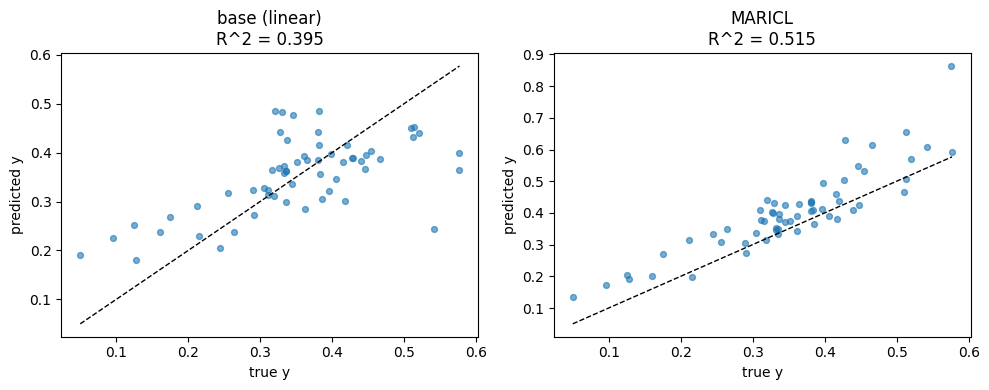

In [15]:
# evaluate on test
base_pred_te = base_reg.predict(X_te)
maricl_pred_te = maricl_reg.predict(X_te)

print(f"{'model':18s}  {'MAE':>8s}  {'R^2':>8s}")
print(f"{'base (linear)':18s}  {mean_absolute_error(y_te, base_pred_te):>8.4f}  {r2_score(y_te, base_pred_te):>8.4f}")
print(f"{'MARICL':18s}  {mean_absolute_error(y_te, maricl_pred_te):>8.4f}  {r2_score(y_te, maricl_pred_te):>8.4f}")

# Visualise predicted vs true
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, name in zip(axes, [base_pred_te, maricl_pred_te], ["base (linear)", "MARICL"]):
    ax.scatter(y_te, pred, alpha=0.6, s=18)
    lo, hi = y_te.min(), y_te.max()
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("true y"); ax.set_ylabel("predicted y")
    ax.set_title(f"{name}\nR^2 = {r2_score(y_te, pred):.3f}")
plt.tight_layout(); plt.show()


### Regression — extra diagnostics

The cells below **only visualize and summarize** ordinary model outputs (`predict`) and sklearn metrics on data already computed above—no MARICL private methods or internal bookkeeping.


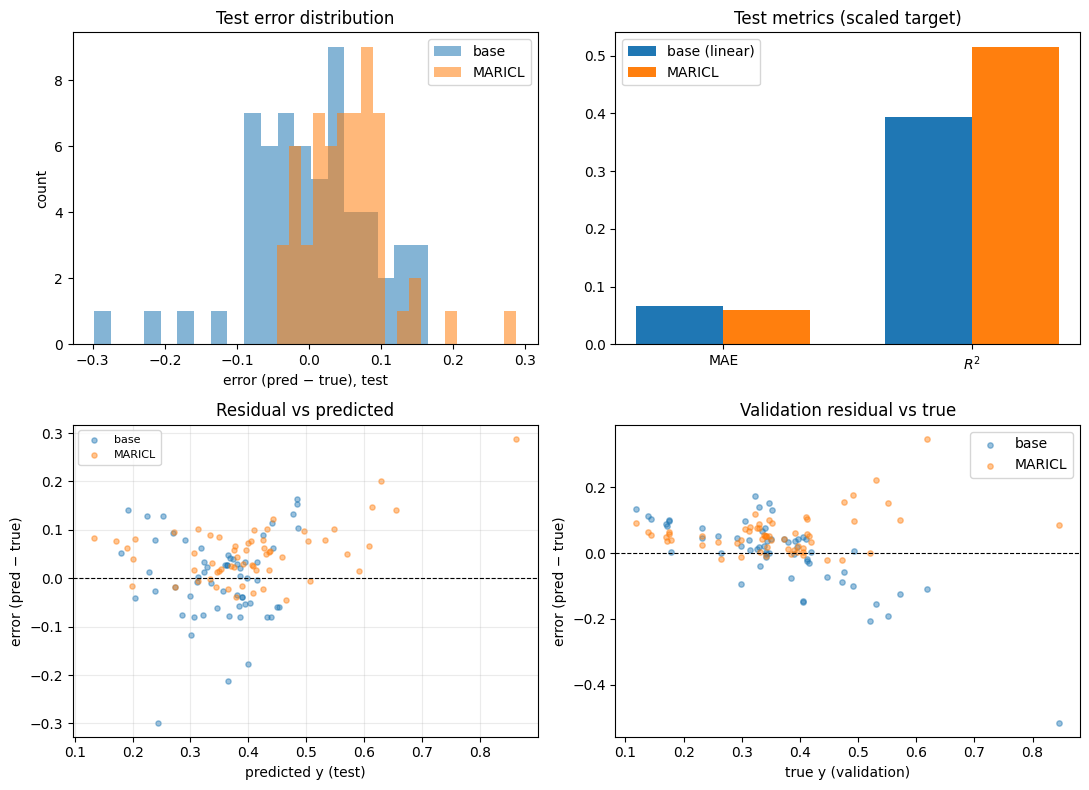

Test summary: ΔMAE (base − MARICL): +0.0066  |  ΔR² (MARICL − base): +0.1202


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
err_base = base_pred_te - y_te
err_m = maricl_pred_te - y_te
axes[0, 0].hist(err_base, bins=20, alpha=0.55, label="base", color="C0")
axes[0, 0].hist(err_m, bins=20, alpha=0.55, label="MARICL", color="C1")
axes[0, 0].set_xlabel("error (pred − true), test")
axes[0, 0].set_ylabel("count")
axes[0, 0].legend()
axes[0, 0].set_title("Test error distribution")

m_names = ["MAE", r"$R^2$"]
bv = [mean_absolute_error(y_te, base_pred_te), r2_score(y_te, base_pred_te)]
mv = [mean_absolute_error(y_te, maricl_pred_te), r2_score(y_te, maricl_pred_te)]
xm = np.arange(len(m_names))
ww = 0.35
axes[0, 1].bar(xm - ww / 2, bv, ww, label="base (linear)")
axes[0, 1].bar(xm + ww / 2, mv, ww, label="MARICL")
axes[0, 1].set_xticks(xm, m_names)
axes[0, 1].legend()
axes[0, 1].set_title("Test metrics (scaled target)")

axes[1, 0].scatter(base_pred_te, err_base, alpha=0.45, s=14, label="base", color="C0")
axes[1, 0].scatter(maricl_pred_te, err_m, alpha=0.45, s=14, label="MARICL", color="C1")
axes[1, 0].axhline(0, color="k", ls="--", lw=0.8)
axes[1, 0].set_xlabel("predicted y (test)")
axes[1, 0].set_ylabel("error (pred − true)")
axes[1, 0].set_title("Residual vs predicted")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.25)

try:
    p_va_b = base_reg.predict(X_va)
    p_va_m = maricl_reg.predict(X_va)
    axes[1, 1].scatter(y_va, p_va_b - y_va, alpha=0.45, s=15, label="base", color="C0")
    axes[1, 1].scatter(y_va, p_va_m - y_va, alpha=0.45, s=15, label="MARICL", color="C1")
    axes[1, 1].axhline(0, color="k", ls="--", lw=0.8)
except NameError:
    axes[1, 1].text(
        0.5,
        0.5,
        "Validation tensors not in scope.",
        ha="center",
        va="center",
        transform=axes[1, 1].transAxes,
    )
    axes[1, 1].set_axis_off()
else:
    axes[1, 1].set_xlabel("true y (validation)")
    axes[1, 1].set_ylabel("error (pred − true)")
    axes[1, 1].set_title("Validation residual vs true")
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

dmae = mean_absolute_error(y_te, base_pred_te) - mean_absolute_error(y_te, maricl_pred_te)
dr2 = r2_score(y_te, maricl_pred_te) - r2_score(y_te, base_pred_te)
print(
    "Test summary: ΔMAE (base − MARICL): "
    f"{dmae:+.4f}  |  ΔR² (MARICL − base): {dr2:+.4f}"
)


## 6. Experiment 2 — synthetic classification

Three-class problem on 4 features. The decision boundary is a nonlinear
combination of features that a *logistic* base model can only partially recover:

* class 0:  $x_1 x_2 < -0.5$
* class 2:  $x_1 x_2 >  0.5$
* class 1:  otherwise  (with a small extra dependence on $x_3^2$)


In [17]:
def make_classification_data(n=500, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, 4))
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    # x3 coefficient raised 0.3→0.5 so the quadratic term creates
    # more distinct failure cases the encoder can discover
    inter = x1 * x2 + 0.5 * (x3**2 - 1.0)
    y = np.full(n, 1, dtype=int)
    y[inter < -0.5] = 0
    y[inter >  0.5] = 2
    # 2% label noise (down from 5%): cleaner residual signal for the encoder
    flip = rng.random(n) < 0.02
    y[flip] = rng.integers(0, 3, size=flip.sum())
    return X, y

Xc, yc = make_classification_data(n=500, seed=0)
print("class counts:", np.bincount(yc))

N = len(Xc)
idx = np.random.RandomState(2).permutation(N)
n_tr, n_va = int(0.6 * N), int(0.2 * N)
tr_i, va_i, te_i = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]
Xc_tr, Xc_va, Xc_te = Xc[tr_i], Xc[va_i], Xc[te_i]
yc_tr, yc_va, yc_te = yc[tr_i], yc[va_i], yc[te_i]

base_clf = LogisticRegression(max_iter=200).fit(Xc_tr, yc_tr)
print(f"\nBase (logistic):")
print(f"  train acc = {accuracy_score(yc_tr, base_clf.predict(Xc_tr)):.3f}")
print(f"  test  acc = {accuracy_score(yc_te, base_clf.predict(Xc_te)):.3f}")
print(f"  test  macroF1 = {f1_score(yc_te, base_clf.predict(Xc_te), average='macro'):.3f}")


class counts: [101 209  90]

Base (logistic):
  train acc = 0.604
  test  acc = 0.613
  test  macroF1 = 0.349


In [18]:
# Classification-specific feature descriptions: hint at interaction structure
# without revealing the exact formula — gives the encoder something to work with
feat_descs_clf = [
    "x1: continuous standardised input; may interact multiplicatively with other features",
    "x2: continuous standardised input; may interact multiplicatively with other features",
    "x3: continuous standardised input; may have a nonlinear (quadratic) effect on class boundaries",
    "x4: continuous standardised input; independent of the class label",
]

# Domain context: describes the failure mode clearly without giving away the formula,
# but tells the decoder what structure the per-class correction should take
domain_clf = (
    "3-class synthetic benchmark. Classes are separated by a nonlinear boundary "
    "involving interactions between x1, x2, and a quadratic effect of x3. "
    "A logistic base model captures only marginal linear effects and systematically "
    "fails when x1 and x2 have the same sign (large positive x1*x2) or opposite signs "
    "(large negative x1*x2). "
    "The target correction is a Python list [delta_0, delta_1, delta_2] where each "
    "delta_c is an arithmetic expression in x1, x2, x3, x4 that scores class c higher "
    "when it is the true class."
)

maricl_clf = MARICL(
    task="classification",
    K=3,
    kappa=0.4,      # was 0.3 — more high-residual examples in encoder context
    T=8,
    tau_fail=0.35,  # was 0.5 — expose borderline cases (P(true)∈[0.35,0.5]) to critique
    beta=0.3,       # was 0.5 — give corrections more weight over the weak logistic base
    verbose=True,
)
maricl_clf.fit(
    Xc_tr, yc_tr,
    base_model=base_clf,
    feature_names=feat_names,
    feature_descs=feat_descs_clf,   # classification-specific descriptions
    domain_context=domain_clf,
    n_classes=3,
)


  high-residual pool: 72 / 240 examples (|r| range 0.683..0.923)
  [correction 0] encoder variant = error_patterns
    hypothesis: The base model misses a positive interaction between x1 and x2, with class_2 activated when x1*x2 is sufficiently large, and it also underestimates the symmetric quadratic contribution of x3 (via |x3| or x3^2) that boosts class_2 even when x3 changes sign.
    form guess: class_2 score delta ≈ softplus(a*(x1*x2 - t)) + b*x3^2, with a compensating decrease to class_1 || class_2 if x1*x2 > a + b*x3^2; class_0 if x1*x2 < -(a + b*x3^2); otherwise class_1 || class_0 score correction ≈ a * ReLU(-(x1*x2) - b*x3^2 - t) or, equivalently, a thresholded softmax on s = x1*x2 + b*x3^2 || piecewise class score driven by alpha*(x1*x2) + beta*(x3^2), with cutpoints/soft thresholds on the interaction magnitude (e.g. saturating tanh(alpha*x1*x2 + beta*x3^2)) || piecewise threshold on a*x1*x2 + b*x3^2, e.g. class score = w1*(x1*x2) + w2*(x3^2 - tau) with saturated regions / c

In [19]:
maricl_clf.show_corrections()



--- Correction 0  (p_k = 0.684, best_t = 8) ---
T_k: This correction emphasizes the bilinear x1*x2 gate for class_2 and adds only a mild symmetric x3^2 booster, so class_2 is no longer driven by x3 alone. It also pushes class_0 up on strongly negative products and suppresses class_1 in the extreme-product / high-|x3| regions, leaving class_1 for the near-neutral middle.
f_k: [1.9*sigmoid(clip(3.6*(-x1*x2 - 0.08), -12, 12)) + 0.25*sigmoid(clip(2.8*(abs(x1*x2) - 0.45), -12, 12)), 0.7*sigmoid(clip(3.0*(0.22 - abs(x1*x2)), -12, 12)) + 0.5*sigmoid(clip(2.6*(0.65 - x3*x3), -12, 12)) - 0.6*sigmoid(clip(3.0*(abs(x1*x2) - 0.25), -12, 12)), 2.0*sigmoid(clip(3.7*(x1*x2 - 0.04), -12, 12)) + 0.8*sigmoid(clip(3.2*(x1*x2 - 0.04), -12, 12))*sigmoid(clip(3.0*(x3*x3 - 0.70), -12, 12)) + 0.22*sigmoid(clip(2.5*(x3*x3 - 0.90), -12, 12))]

--- Correction 1  (p_k = 0.814, best_t = 7) ---
T_k: Use a soft three-way score built from the bilinear interaction x1*x2 plus a clipped quadratic term in x3. Strongly n

In [20]:
base_pred_clf = base_clf.predict(Xc_te)
base_proba_clf = base_clf.predict_proba(Xc_te)
maricl_proba_clf = maricl_clf.predict(Xc_te)
maricl_pred_clf = maricl_proba_clf.argmax(axis=1)

print(f"{'model':18s}  {'acc':>8s}  {'macroF1':>8s}  {'logloss':>8s}")
print(f"{'base (logistic)':18s}  "
      f"{accuracy_score(yc_te, base_pred_clf):>8.3f}  "
      f"{f1_score(yc_te, base_pred_clf, average='macro'):>8.3f}  "
      f"{log_loss(yc_te, base_proba_clf, labels=[0,1,2]):>8.3f}")
print(f"{'MARICL':18s}  "
      f"{accuracy_score(yc_te, maricl_pred_clf):>8.3f}  "
      f"{f1_score(yc_te, maricl_pred_clf, average='macro'):>8.3f}  "
      f"{log_loss(yc_te, maricl_proba_clf, labels=[0,1,2]):>8.3f}")


model                    acc   macroF1   logloss
base (logistic)        0.613     0.349     0.991
MARICL                 0.662     0.574     0.803


### Classification — extra diagnostics

Confusion matrices and metric bars use only `yc_te` and the same prediction tensors as the preceding cell (`base_*` / `maricl_*` probabilities and labels)—sklearn summaries only.


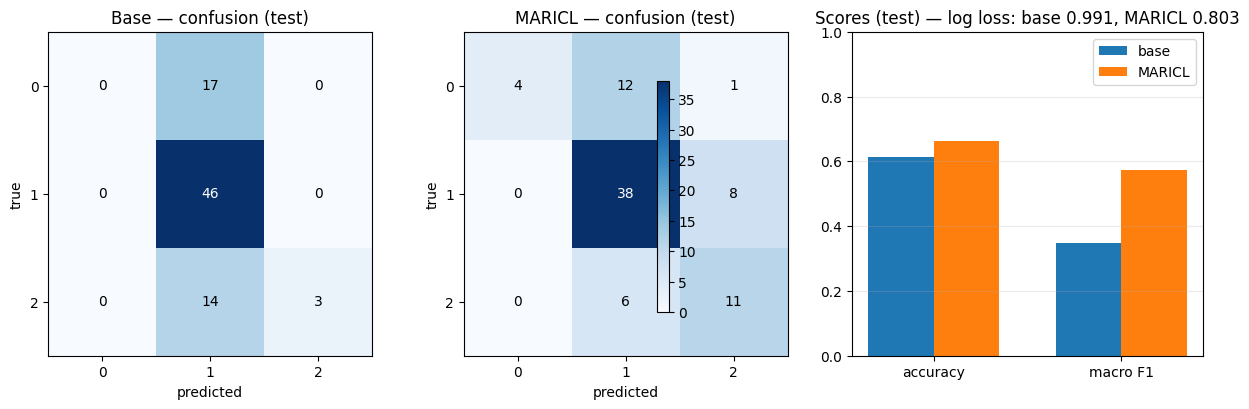

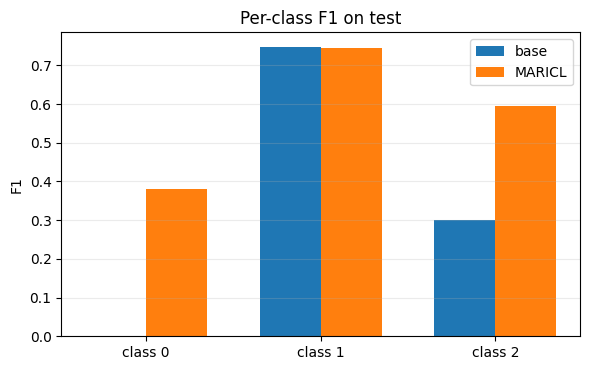

Per-class F1 [0, 1, 2]
  base:   [np.float64(0.0), np.float64(0.748), np.float64(0.3)]
  MARICL: [np.float64(0.381), np.float64(0.745), np.float64(0.595)]


In [21]:
from sklearn.metrics import confusion_matrix

lbl = [0, 1, 2]
Cm_b = confusion_matrix(yc_te, base_pred_clf, labels=lbl)
Cm_m = confusion_matrix(yc_te, maricl_pred_clf, labels=lbl)
ll_b = log_loss(yc_te, base_proba_clf, labels=lbl)
ll_m = log_loss(yc_te, maricl_proba_clf, labels=lbl)
acc_b = accuracy_score(yc_te, base_pred_clf)
acc_m = accuracy_score(yc_te, maricl_pred_clf)
f1_ma_b = f1_score(yc_te, base_pred_clf, average="macro")
f1_ma_m = f1_score(yc_te, maricl_pred_clf, average="macro")
f1_per_b = f1_score(yc_te, base_pred_clf, average=None, labels=lbl)
f1_per_m = f1_score(yc_te, maricl_pred_clf, average=None, labels=lbl)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4))

def plot_cm(ax, C, title):
    im = ax.imshow(C, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    vmax = C.max() if C.max() > 0 else 1
    for (i, j), v in np.ndenumerate(C):
        ax.text(
            j,
            i,
            int(v),
            ha="center",
            va="center",
            color="white" if v > vmax * 0.55 else "black",
        )
    return im

plot_cm(axes[0], Cm_b, "Base — confusion (test)")
im_m = plot_cm(axes[1], Cm_m, "MARICL — confusion (test)")
plt.colorbar(im_m, ax=[axes[0], axes[1]], shrink=0.75)

xbar = np.arange(2); w = 0.35
axes[2].bar(xbar - w / 2, [acc_b, f1_ma_b], w, label="base", color="C0")
axes[2].bar(xbar + w / 2, [acc_m, f1_ma_m], w, label="MARICL", color="C1")
axes[2].set_xticks(xbar, ["accuracy", "macro F1"])
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].set_title(f"Scores (test) — log loss: base {ll_b:.3f}, MARICL {ll_m:.3f}")
axes[2].grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.8))
xk = np.arange(3); w2 = 0.35
plt.bar(xk - w2 / 2, f1_per_b, w2, label="base", color="C0")
plt.bar(xk + w2 / 2, f1_per_m, w2, label="MARICL", color="C1")
plt.xticks(xk, [f"class {c}" for c in lbl])
plt.ylabel("F1")
plt.title("Per-class F1 on test")
plt.legend()
plt.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

print("Per-class F1 [0, 1, 2]")
print(f"  base:   {[round(x, 3) for x in f1_per_b]}")
print(f"  MARICL: {[round(x, 3) for x in f1_per_m]}")


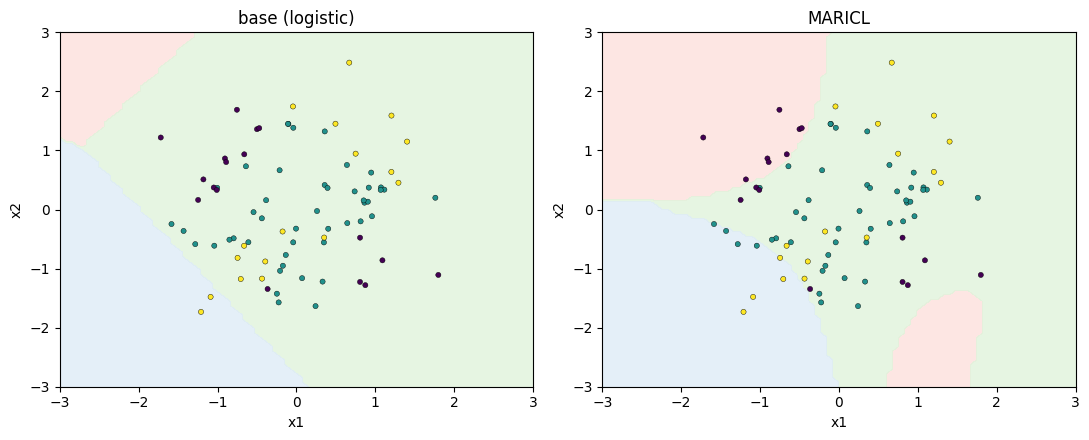

In [22]:
# decision boundary slice: hold x3=x4=0, scan x1 vs x2
xx, yy = np.meshgrid(np.linspace(-3, 3, 80), np.linspace(-3, 3, 80))
grid = np.column_stack([xx.ravel(), yy.ravel(),
                        np.zeros(xx.size), np.zeros(xx.size)])

base_grid = base_clf.predict(grid).reshape(xx.shape)
maricl_grid = maricl_clf.predict_label(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, Z, name in zip(axes, [base_grid, maricl_grid], ["base (logistic)", "MARICL"]):
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=["#fde0dd", "#e0f3db", "#deebf7"], alpha=0.8)
    ax.scatter(Xc_te[:, 0], Xc_te[:, 1], c=yc_te,
               cmap="viridis", s=14, edgecolor="k", linewidth=0.3)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(name)
plt.tight_layout(); plt.show()
